# AdaBN: adapting Model A to a low-light target domain

This notebook applies Adaptive Batch Normalization to the saved Model A checkpoint. No gradient training is performed. The classifier and convolution kernels stay fixed; only the moving mean and moving variance stored by Batch Normalization layers are recalibrated.

The adaptation stream comes from the validation portion of the original training folder. Its labels are not loaded, and its images are converted into a randomized low-light target domain. The test folder is left untouched until the final evaluation.

This is a synthetic target-domain experiment because the project does not contain a separate collection of real low-light photographs. That limitation should be stated when reporting the result.

In [1]:
from pathlib import Path
import json
import shutil
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    top_k_accuracy_score,
)

SEED = 42
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print(f"Python: {sys.version.split()[0]}")
print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}")

Python: 3.13.15
TensorFlow: 2.20.0
GPU available: True


## Paths and fixed settings

AdaBN is applied to Model A rather than to a separately trained network. I use one mixed target stream covering mild through severe low light, so the result is one adapted checkpoint rather than a different checkpoint for every test severity.

The adaptation ranges and number of passes are fixed here before looking at the adapted test scores.

In [2]:
CLASS_NAMES = ['angry', 'happy', 'sad']

DRIVE_DATASET_DIR = Path('/content/drive/MyDrive/Emotions Dataset')
LOCAL_DATASET_DIR = Path('/content/emotions_dataset')
PROJECT_OUTPUT_DIR = Path(
    '/content/drive/MyDrive/CNN-Robustness-Low-Light-Analysis/outputs'
)
OUTPUT_DIR = PROJECT_OUTPUT_DIR / 'adabn'
BASELINE_MODEL_PATH = (
    PROJECT_OUTPUT_DIR / 'model_a' / 'model_a_baseline.keras'
)
ADAPTED_MODEL_PATH = OUTPUT_DIR / 'model_a_adabn.keras'

CONFIG = {
    'image_size': (224, 224),
    'batch_size': 32,
    'validation_split': 0.20,
    'adaptation_passes': 1,
    'gamma_range': (1.20, 1.80),
    'exposure_range': (0.55, 0.85),
    'noise_stddev_range': (0.01, 0.03),
}

CONDITIONS = {
    'clean': {
        'label': 'Clean',
        'gamma': 1.00,
        'exposure': 1.00,
        'noise_stddev': 0.00,
    },
    'mild': {
        'label': 'Mild',
        'gamma': 1.20,
        'exposure': 0.85,
        'noise_stddev': 0.01,
    },
    'moderate': {
        'label': 'Moderate',
        'gamma': 1.50,
        'exposure': 0.70,
        'noise_stddev': 0.02,
    },
    'severe': {
        'label': 'Severe',
        'gamma': 1.80,
        'exposure': 0.55,
        'noise_stddev': 0.03,
    },
}

N_BOOTSTRAP = 2000

display(pd.DataFrame(CONDITIONS).T)
CONFIG

,label,gamma,exposure,noise_stddev
clean,Clean,1.0,1.0,0.0
mild,Mild,1.2,0.85,0.01
moderate,Moderate,1.5,0.7,0.02
severe,Severe,1.8,0.55,0.03


{'image_size': (224, 224),
 'batch_size': 32,
 'validation_split': 0.2,
 'adaptation_passes': 1,
 'gamma_range': (1.2, 1.8),
 'exposure_range': (0.55, 0.85),
 'noise_stddev_range': (0.01, 0.03)}

## Prepare the adaptation and test data

The adaptation dataset uses label_mode=None. TensorFlow therefore returns image batches only, which prevents labels from entering the adaptation step.

The same seeded 20% split used as validation data in Models A-D is used as the image source. The clean test set is loaded separately and is not iterated until after adaptation.

In [3]:
from google.colab import drive

drive.mount('/content/drive')

required_directories = [
    DRIVE_DATASET_DIR / split / class_name
    for split in ['train', 'test']
    for class_name in CLASS_NAMES
]
missing_directories = [
    directory for directory in required_directories
    if not directory.is_dir()
]

if missing_directories:
    missing_text = '\n'.join(str(path) for path in missing_directories)
    raise FileNotFoundError(
        f"The following dataset folders were not found:\n{missing_text}"
    )

if not BASELINE_MODEL_PATH.is_file():
    raise FileNotFoundError(
        f"Model A checkpoint was not found: {BASELINE_MODEL_PATH}"
    )

if not LOCAL_DATASET_DIR.exists():
    print('Copying the dataset from Drive to the Colab runtime...')
    shutil.copytree(DRIVE_DATASET_DIR, LOCAL_DATASET_DIR)
    print('Copy complete.')
else:
    print('Using the dataset already copied to the Colab runtime.')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_DIR = LOCAL_DATASET_DIR / 'train'
TEST_DIR = LOCAL_DATASET_DIR / 'test'

adaptation_index = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=CONFIG['validation_split'],
    subset='validation',
    seed=SEED,
    shuffle=True,
    image_size=CONFIG['image_size'],
    batch_size=CONFIG['batch_size'],
    labels=None,
    label_mode=None,
)

adaptation_file_paths = list(adaptation_index.file_paths)
del adaptation_index


def load_adaptation_image(file_path):
    image_bytes = tf.io.read_file(file_path)
    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])
    return tf.image.resize(image, CONFIG['image_size'])


adaptation_source = (
    tf.data.Dataset.from_tensor_slices(adaptation_file_paths)
    .map(
        load_adaptation_image,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True,
    )
    .batch(CONFIG['batch_size'])
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=CONFIG['image_size'],
    batch_size=CONFIG['batch_size'],
    label_mode='categorical',
    class_names=CLASS_NAMES,
    shuffle=False,
)

adaptation_sample_count = len(adaptation_file_paths)
relative_test_files = [
    str(Path(file_path).relative_to(TEST_DIR))
    for file_path in test_dataset.file_paths
]

print(f"Unlabeled adaptation images: {adaptation_sample_count}")
print(f"Test images reserved for evaluation: {len(relative_test_files)}")

Mounted at /content/drive
Copying the dataset from Drive to the Colab runtime...
Copy complete.
Found 6799 files.
Using 1359 files for validation.
Found 2278 files belonging to 3 classes.
Unlabeled adaptation images: 1359
Test images reserved for evaluation: 2278


## Construct the mixed low-light target stream

Pixels are first scaled from 0-255 to 0-1. Each adaptation image receives independently sampled gamma, exposure, and noise strength:

y = clip(exposure × x^gamma + noise, 0, 1).

Every adaptation image is corrupted because this stream represents the target domain. Stateless random numbers make the stream repeatable.

In [4]:
def apply_random_target_condition(images, batch_index):
    images = tf.cast(images, tf.float32) / 255.0
    images = tf.clip_by_value(images, 0.0, 1.0)

    seed = tf.stack([
        tf.constant(SEED + 1000, dtype=tf.int32),
        tf.cast(batch_index, tf.int32),
    ])
    parameter_seeds = tf.random.experimental.stateless_split(
        seed,
        num=4,
    )
    parameter_shape = [tf.shape(images)[0], 1, 1, 1]

    gamma = tf.random.stateless_uniform(
        parameter_shape,
        seed=parameter_seeds[0],
        minval=CONFIG['gamma_range'][0],
        maxval=CONFIG['gamma_range'][1],
        dtype=tf.float32,
    )
    exposure = tf.random.stateless_uniform(
        parameter_shape,
        seed=parameter_seeds[1],
        minval=CONFIG['exposure_range'][0],
        maxval=CONFIG['exposure_range'][1],
        dtype=tf.float32,
    )
    noise_stddev = tf.random.stateless_uniform(
        parameter_shape,
        seed=parameter_seeds[2],
        minval=CONFIG['noise_stddev_range'][0],
        maxval=CONFIG['noise_stddev_range'][1],
        dtype=tf.float32,
    )
    noise = tf.random.stateless_normal(
        tf.shape(images),
        seed=parameter_seeds[3],
        dtype=tf.float32,
    )

    target_images = (
        exposure * tf.pow(images, gamma)
        + noise_stddev * noise
    )
    target_images = tf.clip_by_value(target_images, 0.0, 1.0)
    return target_images * 255.0


def prepare_adaptation_batch(batch_index, images):
    return apply_random_target_condition(images, batch_index)


adaptation_dataset = (
    adaptation_source
    .enumerate()
    .map(
        prepare_adaptation_batch,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True,
    )
    .prefetch(tf.data.AUTOTUNE)
)

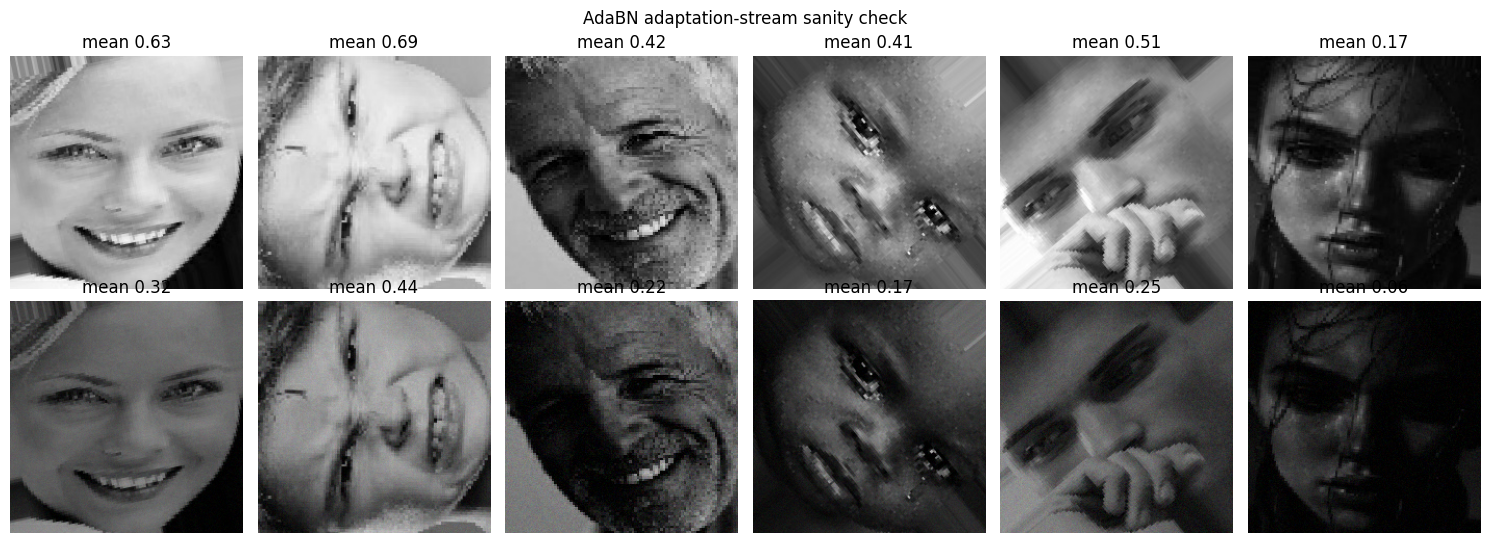

In [5]:
preview_source = next(iter(adaptation_source))[:6]
preview_target = apply_random_target_condition(
    preview_source,
    tf.constant(0, dtype=tf.int64),
)

fig, axes = plt.subplots(2, len(preview_source), figsize=(15, 5.5))

for column in range(len(preview_source)):
    source_image = preview_source[column].numpy().astype('uint8')
    target_image = preview_target[column].numpy().astype('uint8')

    axes[0, column].imshow(source_image)
    axes[0, column].set_title(
        f"mean {source_image.mean() / 255:.2f}"
    )
    axes[0, column].axis('off')

    axes[1, column].imshow(target_image)
    axes[1, column].set_title(
        f"mean {target_image.mean() / 255:.2f}"
    )
    axes[1, column].axis('off')

axes[0, 0].set_ylabel('Source')
axes[1, 0].set_ylabel('Target')
fig.suptitle('AdaBN adaptation-stream sanity check')
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / 'adaptation_preview.png',
    dpi=200,
    bbox_inches='tight',
)
plt.show()

## Configure Batch Normalization recalibration

Model A called its EfficientNet backbone with training=False during classifier training. Calling the complete saved model with training=True would therefore still leave the backbone in inference mode.

For adaptation I call the nested EfficientNet backbone directly with training=True. Convolution and classifier parameters are frozen. Batch Normalization layers are enabled only so that their moving statistics can update; no optimizer, loss, labels, or gradient tape is used.

In [6]:
adapted_model = tf.keras.models.load_model(
    str(BASELINE_MODEL_PATH),
    compile=False,
)

backbone_candidates = [
    layer for layer in adapted_model.layers
    if isinstance(layer, tf.keras.Model)
    and 'efficientnet' in layer.name.lower()
]

if len(backbone_candidates) != 1:
    candidate_names = [layer.name for layer in adapted_model.layers]
    raise RuntimeError(
        'Expected one nested EfficientNet backbone. '
        f'Found these top-level layers instead: {candidate_names}'
    )

backbone = backbone_candidates[0]

for layer in adapted_model.layers:
    layer.trainable = False

backbone.trainable = True
batch_norm_layers = []

for layer in backbone.layers:
    is_batch_norm = isinstance(
        layer,
        tf.keras.layers.BatchNormalization,
    )
    layer.trainable = is_batch_norm
    if is_batch_norm:
        batch_norm_layers.append(layer)

trainable_layer_names = [
    layer.name for layer in backbone.layers if layer.trainable
]

print(f"Backbone: {backbone.name}")
print(f"Batch Normalization layers enabled: {len(batch_norm_layers)}")
print(f"Other trainable backbone layers: {len(trainable_layer_names) - len(batch_norm_layers)}")

Backbone: efficientnetb0
Batch Normalization layers enabled: 49
Other trainable backbone layers: 0


## Run one label-free adaptation pass

I take a copy of every model variable before the forward pass. Afterward, the notebook stops with an error if anything other than a Batch Normalization moving mean or moving variance changed.

EfficientNet uses dropout internally for stochastic depth. Its dropout rates are temporarily set to zero while collecting statistics so that AdaBN itself is the only source of model-state change.

In [7]:
tracked_variables = [
    (
        variable,
        variable.numpy().copy(),
        getattr(variable, 'path', variable.name),
    )
    for variable in adapted_model.weights
]

dropout_rates = [
    (layer, layer.rate)
    for layer in backbone.layers
    if isinstance(layer, tf.keras.layers.Dropout)
]

for layer, _ in dropout_rates:
    layer.rate = 0.0

adaptation_batches = 0
tf.keras.utils.set_random_seed(SEED)

try:
    for pass_index in range(CONFIG['adaptation_passes']):
        print(
            f"Adaptation pass "
            f"{pass_index + 1}/{CONFIG['adaptation_passes']}"
        )
        for batch_index, target_images in enumerate(
            adaptation_dataset,
            start=1,
        ):
            backbone(target_images, training=True)
            adaptation_batches += 1

            if batch_index % 25 == 0:
                print(f"  processed {batch_index} batches")
finally:
    for layer, original_rate in dropout_rates:
        layer.rate = original_rate

changed_rows = []

for variable, before_value, variable_name in tracked_variables:
    max_abs_change = float(
        np.max(np.abs(variable.numpy() - before_value))
    )

    if max_abs_change > 1e-12:
        if 'moving_mean' in variable_name:
            change_type = 'moving_mean'
        elif 'moving_variance' in variable_name:
            change_type = 'moving_variance'
        else:
            change_type = 'unexpected'

        changed_rows.append({
            'variable': variable_name,
            'change_type': change_type,
            'max_abs_change': max_abs_change,
        })

variable_changes = pd.DataFrame(
    changed_rows,
    columns=['variable', 'change_type', 'max_abs_change'],
)
unexpected_changes = variable_changes[
    variable_changes['change_type'] == 'unexpected'
]

if variable_changes.empty:
    raise RuntimeError(
        'No Batch Normalization statistics changed during adaptation.'
    )

if not unexpected_changes.empty:
    display(unexpected_changes)
    raise RuntimeError(
        'AdaBN changed variables outside moving means and variances.'
    )

backbone.trainable = False
adapted_model.save(str(ADAPTED_MODEL_PATH))

print(f"Adaptation batches processed: {adaptation_batches}")
print(f"BN state variables changed: {len(variable_changes)}")
print("Kernel and classifier variables changed: 0")
print(f"Saved adapted checkpoint: {ADAPTED_MODEL_PATH}")

display(
    variable_changes
    .groupby('change_type')
    .agg(
        variables=('variable', 'count'),
        largest_change=('max_abs_change', 'max'),
    )
)

Adaptation pass 1/1
  processed 25 batches
Adaptation batches processed: 43
BN state variables changed: 98
Kernel and classifier variables changed: 0
Saved adapted checkpoint: /content/drive/MyDrive/CNN-Robustness-Low-Light-Analysis/outputs/adabn/model_a_adabn.keras


,variables,largest_change
change_type,,
moving_mean,49,1.665925
moving_variance,49,178.570007


## Evaluate before and after AdaBN

Both checkpoints now receive exactly the same clean and corrupted test images. The corruption code and seeds match the earlier robustness-evaluation notebook, which makes each accuracy difference paired by image.

In [8]:
def apply_fixed_condition(images, batch_index, settings):
    images = tf.cast(images, tf.float32) / 255.0
    images = tf.clip_by_value(images, 0.0, 1.0)

    seed = tf.stack([
        tf.constant(SEED, dtype=tf.int64),
        tf.cast(batch_index, tf.int64),
    ])
    base_noise = tf.random.stateless_normal(
        shape=tf.shape(images),
        seed=seed,
        dtype=tf.float32,
    )

    corrupted = (
        settings['exposure'] * tf.pow(images, settings['gamma'])
        + settings['noise_stddev'] * base_noise
    )
    return tf.clip_by_value(corrupted, 0.0, 1.0) * 255.0


def make_condition_dataset(settings):
    def transform(batch_index, batch):
        images, labels = batch
        corrupted_images = apply_fixed_condition(
            images,
            batch_index,
            settings,
        )
        return corrupted_images, labels

    return (
        test_dataset
        .enumerate()
        .map(
            transform,
            num_parallel_calls=tf.data.AUTOTUNE,
            deterministic=True,
        )
        .prefetch(tf.data.AUTOTUNE)
    )


condition_datasets = {
    condition_name: make_condition_dataset(settings)
    for condition_name, settings in CONDITIONS.items()
}

true_labels = np.concatenate([
    np.argmax(batch_labels.numpy(), axis=1)
    for _, batch_labels in test_dataset
])

baseline_model = tf.keras.models.load_model(
    str(BASELINE_MODEL_PATH),
    compile=False,
)
adapted_model = tf.keras.models.load_model(
    str(ADAPTED_MODEL_PATH),
    compile=False,
)

MODELS = {
    'A': baseline_model,
    'AdaBN': adapted_model,
}
MODEL_LABELS = {
    'A': 'Model A: baseline',
    'AdaBN': 'Model A + AdaBN',
}

In [9]:
metric_rows = []
per_class_rows = []
prediction_frames = []
predictions_by_key = {}

model_order = list(MODELS)
condition_order = list(CONDITIONS)

for model_key, model in MODELS.items():
    print(f"\nEvaluating {MODEL_LABELS[model_key]}")

    for severity_index, condition_name in enumerate(condition_order):
        settings = CONDITIONS[condition_name]
        probabilities = model.predict(
            condition_datasets[condition_name],
            verbose=0,
        )
        predicted_labels = np.argmax(probabilities, axis=1)
        predictions_by_key[(model_key, condition_name)] = (
            predicted_labels.copy()
        )

        report = classification_report(
            true_labels,
            predicted_labels,
            target_names=CLASS_NAMES,
            output_dict=True,
            zero_division=0,
        )

        metric_rows.append({
            'model': model_key,
            'model_label': MODEL_LABELS[model_key],
            'condition': condition_name,
            'condition_label': settings['label'],
            'severity_index': severity_index,
            'cross_entropy': float(log_loss(
                true_labels,
                probabilities,
                labels=np.arange(len(CLASS_NAMES)),
            )),
            'accuracy': float(accuracy_score(
                true_labels,
                predicted_labels,
            )),
            'top_2_accuracy': float(top_k_accuracy_score(
                true_labels,
                probabilities,
                k=2,
                labels=np.arange(len(CLASS_NAMES)),
            )),
            'macro_f1': float(f1_score(
                true_labels,
                predicted_labels,
                average='macro',
            )),
            'weighted_f1': float(f1_score(
                true_labels,
                predicted_labels,
                average='weighted',
            )),
        })

        for class_name in CLASS_NAMES:
            class_result = report[class_name]
            per_class_rows.append({
                'model': model_key,
                'condition': condition_name,
                'class': class_name,
                'precision': float(class_result['precision']),
                'recall': float(class_result['recall']),
                'f1': float(class_result['f1-score']),
                'support': int(class_result['support']),
            })

        prediction_frame = pd.DataFrame({
            'model': model_key,
            'condition': condition_name,
            'file': relative_test_files,
            'true_label': [
                CLASS_NAMES[index] for index in true_labels
            ],
            'predicted_label': [
                CLASS_NAMES[index] for index in predicted_labels
            ],
        })
        for class_index, class_name in enumerate(CLASS_NAMES):
            prediction_frame[f'prob_{class_name}'] = (
                probabilities[:, class_index]
            )
        prediction_frames.append(prediction_frame)

metrics_table = pd.DataFrame(metric_rows)
per_class_table = pd.DataFrame(per_class_rows)
all_predictions = pd.concat(prediction_frames, ignore_index=True)

accuracy_table = (
    metrics_table
    .pivot(index='model', columns='condition', values='accuracy')
    .reindex(index=model_order, columns=condition_order)
)
macro_f1_table = (
    metrics_table
    .pivot(index='model', columns='condition', values='macro_f1')
    .reindex(index=model_order, columns=condition_order)
)

print('\nAccuracy')
display(accuracy_table.style.format('{:.4f}'))
print('Macro-F1')
display(macro_f1_table.style.format('{:.4f}'))


Evaluating Model A: baseline

Evaluating Model A + AdaBN

Accuracy


condition,clean,mild,moderate,severe
model,,,,
A,0.8169,0.8139,0.7796,0.7142
AdaBN,0.7138,0.7818,0.7550,0.6949


Macro-F1


condition,clean,mild,moderate,severe
model,,,,
A,0.8028,0.8001,0.7636,0.6931
AdaBN,0.6873,0.7651,0.7393,0.6680


## Robustness curves and summary

Clean performance is included to show the trade-off, but the main AdaBN question concerns the low-light target conditions. An improvement is not assumed: replacing source-domain BN statistics can also hurt if the target stream is not representative.

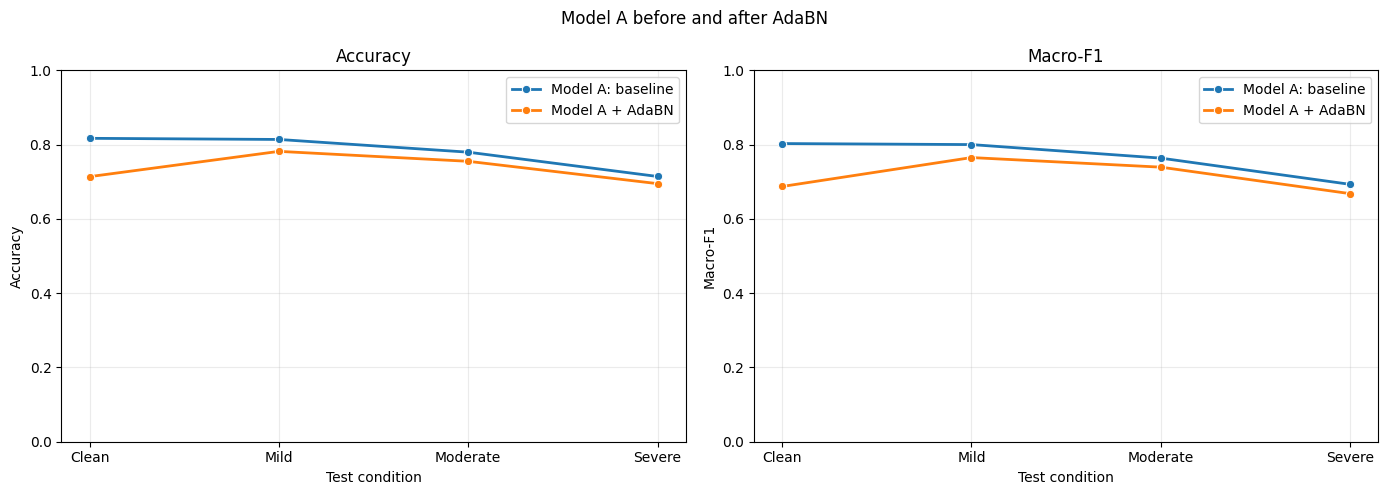

,model,model_label,clean_accuracy,mean_corrupted_accuracy,severe_accuracy,clean_to_severe_accuracy_drop,clean_macro_f1,mean_corrupted_macro_f1,severe_macro_f1
0,A,Model A: baseline,0.8169,0.7692,0.7142,0.1027,0.8028,0.7523,0.6931
1,AdaBN,Model A + AdaBN,0.7138,0.7439,0.6949,0.0189,0.6873,0.7241,0.6680


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for axis, metric_name, title in [
    (axes[0], 'accuracy', 'Accuracy'),
    (axes[1], 'macro_f1', 'Macro-F1'),
]:
    sns.lineplot(
        data=metrics_table,
        x='severity_index',
        y=metric_name,
        hue='model_label',
        hue_order=[MODEL_LABELS[key] for key in model_order],
        marker='o',
        linewidth=2,
        ax=axis,
    )
    axis.set_xticks(
        range(len(condition_order)),
        [CONDITIONS[name]['label'] for name in condition_order],
    )
    axis.set_ylim(0, 1)
    axis.set_xlabel('Test condition')
    axis.set_ylabel(title)
    axis.set_title(title)
    axis.grid(alpha=0.25)
    axis.legend(title='')

fig.suptitle('Model A before and after AdaBN')
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / 'adabn_robustness_curves.png',
    dpi=200,
    bbox_inches='tight',
)
plt.show()

summary_rows = []

for model_key in model_order:
    model_metrics = (
        metrics_table[metrics_table['model'] == model_key]
        .set_index('condition')
    )
    corrupted_metrics = model_metrics.loc[
        ['mild', 'moderate', 'severe']
    ]

    summary_rows.append({
        'model': model_key,
        'model_label': MODEL_LABELS[model_key],
        'clean_accuracy': float(
            model_metrics.loc['clean', 'accuracy']
        ),
        'mean_corrupted_accuracy': float(
            corrupted_metrics['accuracy'].mean()
        ),
        'severe_accuracy': float(
            model_metrics.loc['severe', 'accuracy']
        ),
        'clean_to_severe_accuracy_drop': float(
            model_metrics.loc['clean', 'accuracy']
            - model_metrics.loc['severe', 'accuracy']
        ),
        'clean_macro_f1': float(
            model_metrics.loc['clean', 'macro_f1']
        ),
        'mean_corrupted_macro_f1': float(
            corrupted_metrics['macro_f1'].mean()
        ),
        'severe_macro_f1': float(
            model_metrics.loc['severe', 'macro_f1']
        ),
    })

robustness_summary = pd.DataFrame(summary_rows)

display(robustness_summary.style.format({
    'clean_accuracy': '{:.4f}',
    'mean_corrupted_accuracy': '{:.4f}',
    'severe_accuracy': '{:.4f}',
    'clean_to_severe_accuracy_drop': '{:.4f}',
    'clean_macro_f1': '{:.4f}',
    'mean_corrupted_macro_f1': '{:.4f}',
    'severe_macro_f1': '{:.4f}',
}))

## Normalized confusion matrices

Rows are true classes and columns are predicted classes. Row normalization makes changes within angry, happy, and sad visible despite their different sample counts.

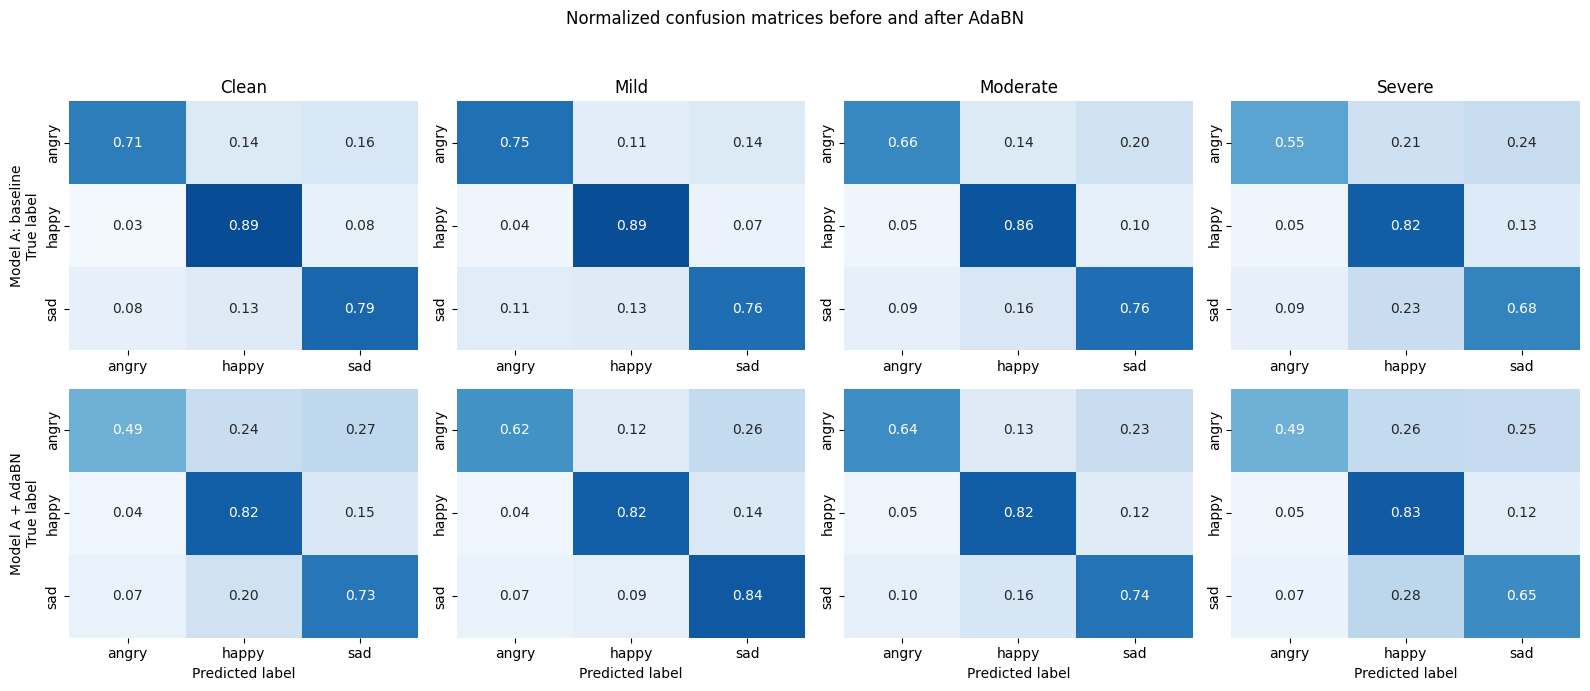

In [11]:
fig, axes = plt.subplots(
    len(model_order),
    len(condition_order),
    figsize=(16, 7),
)

for model_index, model_key in enumerate(model_order):
    for condition_index, condition_name in enumerate(condition_order):
        matrix = confusion_matrix(
            true_labels,
            predictions_by_key[(model_key, condition_name)],
            labels=np.arange(len(CLASS_NAMES)),
            normalize='true',
        )

        axis = axes[model_index, condition_index]
        sns.heatmap(
            matrix,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            vmin=0,
            vmax=1,
            cbar=False,
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            ax=axis,
        )

        if model_index == 0:
            axis.set_title(CONDITIONS[condition_name]['label'])
        if condition_index == 0:
            axis.set_ylabel(
                f"{MODEL_LABELS[model_key]}\nTrue label"
            )
        else:
            axis.set_ylabel('')
        if model_index == len(model_order) - 1:
            axis.set_xlabel('Predicted label')
        else:
            axis.set_xlabel('')

fig.suptitle('Normalized confusion matrices before and after AdaBN')
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(
    OUTPUT_DIR / 'normalized_confusion_matrices.png',
    dpi=200,
    bbox_inches='tight',
)
plt.show()

## Paired accuracy differences

For each condition, the difference is computed per test image as AdaBN-correct minus baseline-correct. The bootstrap interval therefore respects the pairing. It measures uncertainty from this finite test set; it does not replace repeating the original model training with several seeds.

In [12]:
bootstrap_rows = []

for condition_index, condition_name in enumerate(condition_order):
    adapted_correct = (
        predictions_by_key[('AdaBN', condition_name)]
        == true_labels
    ).astype(np.float32)
    baseline_correct = (
        predictions_by_key[('A', condition_name)]
        == true_labels
    ).astype(np.float32)
    paired_differences = adapted_correct - baseline_correct

    rng = np.random.default_rng(SEED + condition_index)
    bootstrap_indices = rng.integers(
        0,
        len(true_labels),
        size=(N_BOOTSTRAP, len(true_labels)),
        dtype=np.int32,
    )
    bootstrap_differences = (
        paired_differences[bootstrap_indices].mean(axis=1)
    )

    bootstrap_rows.append({
        'condition': condition_name,
        'accuracy_difference': float(
            paired_differences.mean()
        ),
        'ci_95_lower': float(
            np.quantile(bootstrap_differences, 0.025)
        ),
        'ci_95_upper': float(
            np.quantile(bootstrap_differences, 0.975)
        ),
    })

paired_accuracy_differences = pd.DataFrame(bootstrap_rows)

display(paired_accuracy_differences.style.format({
    'accuracy_difference': '{:+.4f}',
    'ci_95_lower': '{:+.4f}',
    'ci_95_upper': '{:+.4f}',
}))

,condition,accuracy_difference,ci_95_lower,ci_95_upper
0,clean,-0.1032,-0.1220,-0.0852
1,mild,-0.0320,-0.0483,-0.0158
2,moderate,-0.0246,-0.0395,-0.0101
3,severe,-0.0193,-0.0338,-0.0053


## Save the experiment

The adapted checkpoint, exact metrics, per-image predictions, BN-state audit, and paired intervals are saved together. These files are enough to reproduce the final comparison without adapting the model again.

In [13]:
metrics_table.to_csv(
    OUTPUT_DIR / 'metrics_by_condition.csv',
    index=False,
)
per_class_table.to_csv(
    OUTPUT_DIR / 'per_class_metrics.csv',
    index=False,
)
all_predictions.to_csv(
    OUTPUT_DIR / 'predictions_all_conditions.csv',
    index=False,
)
robustness_summary.to_csv(
    OUTPUT_DIR / 'robustness_summary.csv',
    index=False,
)
paired_accuracy_differences.to_csv(
    OUTPUT_DIR / 'paired_accuracy_differences.csv',
    index=False,
)
variable_changes.to_csv(
    OUTPUT_DIR / 'bn_variable_changes.csv',
    index=False,
)

results_summary = {
    'experiment': 'AdaBN adaptation of Model A',
    'seed': SEED,
    'tensorflow_version': tf.__version__,
    'baseline_model_path': str(BASELINE_MODEL_PATH),
    'adapted_model_path': str(ADAPTED_MODEL_PATH),
    'adaptation_source': (
        'Validation subset of the original training folder, '
        'converted to a synthetic mixed low-light target domain'
    ),
    'adaptation_labels_loaded': False,
    'adaptation_samples': adaptation_sample_count,
    'adaptation_batches_processed': adaptation_batches,
    'adaptation_passes': CONFIG['adaptation_passes'],
    'adaptation_ranges': {
        'gamma': list(CONFIG['gamma_range']),
        'exposure': list(CONFIG['exposure_range']),
        'noise_stddev_normalized': list(
            CONFIG['noise_stddev_range']
        ),
    },
    'batch_normalization_layers': len(batch_norm_layers),
    'bn_state_variables_changed': len(variable_changes),
    'unexpected_variables_changed': 0,
    'dropout_disabled_during_statistic_collection': True,
    'test_samples': int(len(true_labels)),
    'conditions': CONDITIONS,
    'bootstrap_replicates': N_BOOTSTRAP,
    'metrics': json.loads(
        metrics_table.to_json(orient='records')
    ),
    'robustness_summary': json.loads(
        robustness_summary.to_json(orient='records')
    ),
    'paired_accuracy_differences': json.loads(
        paired_accuracy_differences.to_json(orient='records')
    ),
    'limitation': (
        'Adaptation uses synthetic low-light images rather than '
        'a separately collected real target-domain dataset.'
    ),
}

with open(OUTPUT_DIR / 'results_summary.json', 'w') as file:
    json.dump(results_summary, file, indent=2)

print(f"\nSaved all AdaBN outputs to: {OUTPUT_DIR}")


Saved all AdaBN outputs to: /content/drive/MyDrive/CNN-Robustness-Low-Light-Analysis/outputs/adabn
